# 01 — Fire Data Exploration and Weekly Target Construction

This notebook prepares the wildfire component of the project from the ICNF/SGIF fire records and defines the common spatial-temporal modelling unit.

The final modelling unit is:

> **one 5 × 5 km grid cell × one weekly reference date (Monday)**

For each weekly row:

- all predictor information must be available **before** the reference date;
- the target period is the following Monday–Sunday interval;
- `fire_next_7_days = 1` when at least one recorded wildfire occurs in that cell during the target week.

The notebook has four objectives:

1. load and audit the 2017–2025 fire records;
2. retain only observations located inside Mainland Portugal;
3. construct the fixed 5 × 5 km prediction grid;
4. create the weekly binary wildfire target used by all later models.

Only the exploratory results that directly support project decisions are retained here.

## 1. Data loading

Two SGIF files are combined:

- `Registos_Incendios_SGIF_2011_2020.xlsx`
- `Registos_Incendios_SGIF_2021_2025.xlsx`

Both files contain the same 41 columns. The project scope begins in **2017**, matching the temporal coverage selected for the satellite component.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import geopandas as gpd

from shapely.geometry import box

In [3]:
df_2011_2020 = pd.read_excel(
    "../data/raw/Registos_Incendios_SGIF_2011_2020.xlsx"
)

df_2021_2025 = pd.read_excel(
    "../data/raw/Registos_Incendios_SGIF_2021_2025.xlsx"
)

assert df_2011_2020.columns.equals(
    df_2021_2025.columns
)

fires = pd.concat(
    [df_2011_2020, df_2021_2025],
    ignore_index=True
)

fires_2017_2025 = (
    fires[
        fires["Ano"].between(2017, 2025)
    ]
    .copy()
)

print("2017–2025 records:", len(fires_2017_2025))
print("Columns:", len(fires_2017_2025.columns))

2017–2025 records: 94337
Columns: 41


### Data-quality audit

The original exploration found **94,337 fire records** between 2017 and 2025.

Checks retained for the project:

- no negative burned-area values;
- `AreaTotal_ha` equals the sum of forest, shrubland and agricultural burned area for all records;
- year/month/day fields agree with `DataHoraAlerta`;
- `Codigo_SGIF` has no duplicates;
- 1,267 records have `DataHora_PrimeiraIntervencao > DataHora_Extincao`.

The anomalous intervention/extinction ordering is documented but does not affect the modelling dataset because response duration is not used as a predictor. The wildfire occurrence date comes from `DataHoraAlerta`.

In [4]:
fires_2017_2025["Distrito"] = (
    fires_2017_2025["Distrito"]
    .replace({
        "Viana Do Castelo": "Viana do Castelo"
    })
)

area_sum = (
    fires_2017_2025["AreaPov_ha"]
    + fires_2017_2025["AreaMato_ha"]
    + fires_2017_2025["AreaAgric_ha"]
)

quality_audit = pd.Series({
    "negative_total_area":
        (fires_2017_2025["AreaTotal_ha"] < 0).sum(),
    "area_sum_mismatches":
        (~np.isclose(
            fires_2017_2025["AreaTotal_ha"],
            area_sum
        )).sum(),
    "duplicate_codigo_sgif":
        fires_2017_2025["Codigo_SGIF"]
        .duplicated()
        .sum(),
    "alert_year_mismatches":
        (
            fires_2017_2025["Ano"]
            != fires_2017_2025["DataHoraAlerta"].dt.year
        ).sum(),
    "alert_month_mismatches":
        (
            fires_2017_2025["Mes"]
            != fires_2017_2025["DataHoraAlerta"].dt.month
        ).sum(),
    "alert_day_mismatches":
        (
            fires_2017_2025["Dia"]
            != fires_2017_2025["DataHoraAlerta"].dt.day
        ).sum(),
    "intervention_after_extinction":
        (
            fires_2017_2025["DataHora_PrimeiraIntervencao"]
            > fires_2017_2025["DataHora_Extincao"]
        ).sum()
})

quality_audit

negative_total_area                 0
area_sum_mismatches                 0
duplicate_codigo_sgif               0
alert_year_mismatches               0
alert_month_mismatches              0
alert_day_mismatches                0
intervention_after_extinction    1267
dtype: int64

## 2. Fire activity relevant to the modelling scope

Wildfire frequency and wildfire severity are not the same phenomenon.

Across the original 2017–2025 exploration:

- 2017 contained **21,006 occurrences** and approximately **539,921 ha** burned;
- 2025 contained **8,252 occurrences** but approximately **270,695 ha** burned;
- median fire size remained very small;
- a small number of large events produced most of the burned area.

For example, fires larger than 100 ha represented only about **1.29%** of 2017 occurrences but approximately **93.67%** of burned area. In 2025, they represented about **1.22%** of occurrences and approximately **95.64%** of burned area.

These observations justify treating this project as an **occurrence-risk** problem rather than attempting to infer wildfire severity from the binary target.

In [5]:
yearly_summary = (
    fires_2017_2025
    .groupby("Ano")
    .agg(
        fire_occurrences=("Codigo_SGIF", "size"),
        burned_area_ha=("AreaTotal_ha", "sum"),
        mean_fire_area_ha=("AreaTotal_ha", "mean"),
        median_fire_area_ha=("AreaTotal_ha", "median")
    )
    .round(2)
)

fires_over_100 = (
    fires_2017_2025[
        fires_2017_2025["AreaTotal_ha"] > 100
    ]
)

large_fire_area_share = (
    fires_over_100
    .groupby("Ano")["AreaTotal_ha"]
    .sum()
    .div(
        fires_2017_2025
        .groupby("Ano")["AreaTotal_ha"]
        .sum()
    )
    .mul(100)
    .round(2)
    .rename("burned_area_from_fires_over_100ha_pct")
)

yearly_summary.join(
    large_fire_area_share
)

,fire_occurrences,burned_area_ha,mean_fire_area_ha,median_fire_area_ha,burned_area_from_fires_over_100ha_pct
Ano,,,,,
2017,21006,539921.00,25.70,0.08,93.67
2018,12274,44577.50,3.63,0.05,76.66
2019,10832,42083.92,3.89,0.05,64.79
2020,9619,67169.93,6.98,0.05,82.57
2021,8186,28360.01,3.46,0.07,53.09
2022,10390,110097.06,10.60,0.06,84.50
2023,7523,34509.21,4.59,0.05,68.73
2024,6255,137651.42,22.01,0.05,92.41
2025,8252,270695.11,32.80,0.06,95.64


### 2.1 Seasonal concentration

The modelling season is restricted to **May–October**.

In the original exploration, these six months contained approximately **77.4% of recorded fire occurrences** and more than **95% of total burned area**.

This has three advantages:

- it focuses prediction on the principal wildfire season;
- it avoids filling the dataset with relatively easy winter negatives;
- it aligns better with the period in which useful Sentinel-2 vegetation observations are expected to be most relevant.

The following visual is retained because it directly supports this temporal decision.

In [6]:
monthly_summary = (
    fires_2017_2025
    .groupby("Mes")
    .agg(
        fire_occurrences=("Codigo_SGIF", "size"),
        burned_area_ha=("AreaTotal_ha", "sum")
    )
)

monthly_summary["occurrence_share_pct"] = (
    monthly_summary["fire_occurrences"]
    / monthly_summary["fire_occurrences"].sum()
    * 100
)

monthly_summary["burned_area_share_pct"] = (
    monthly_summary["burned_area_ha"]
    / monthly_summary["burned_area_ha"].sum()
    * 100
)

monthly_summary.round(2)

,fire_occurrences,burned_area_ha,occurrence_share_pct,burned_area_share_pct
Mes,,,,
1,2520,11275.23,2.67,0.88
2,4607,11051.59,4.88,0.87
3,5544,19965.67,5.88,1.57
4,6280,14331.59,6.66,1.12
5,8068,7058.49,8.55,0.55
6,8629,70580.39,9.15,5.54
7,15862,196726.60,16.81,15.43
8,19116,441042.86,20.26,34.59
9,12517,199581.51,13.27,15.65


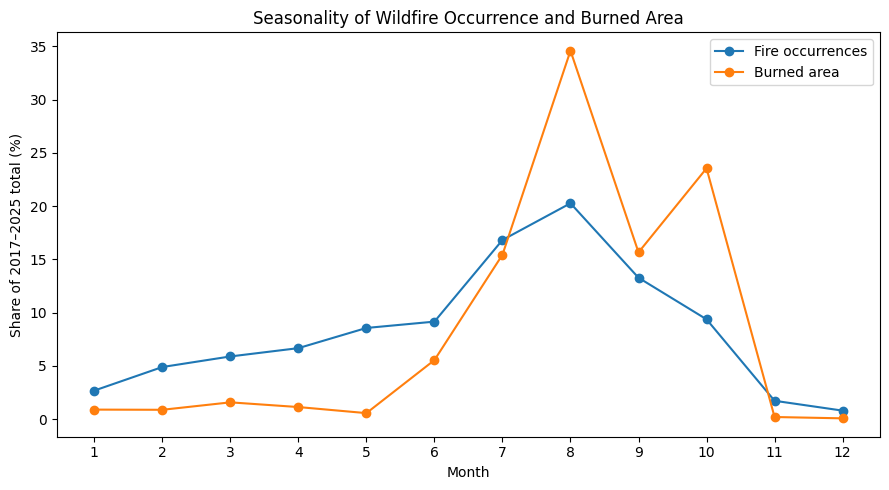

In [7]:
plt.figure(figsize=(9, 5))

plt.plot(
    monthly_summary.index,
    monthly_summary["occurrence_share_pct"],
    marker="o",
    label="Fire occurrences"
)

plt.plot(
    monthly_summary.index,
    monthly_summary["burned_area_share_pct"],
    marker="o",
    label="Burned area"
)

plt.xticks(range(1, 13))
plt.xlabel("Month")
plt.ylabel("Share of 2017–2025 total (%)")
plt.title("Seasonality of Wildfire Occurrence and Burned Area")
plt.legend()
plt.tight_layout()
plt.show()

The seasonal signal is clear but the two series are not identical. August has the largest number of occurrences and the greatest total burned area, while October contains fewer fires than July–September but a disproportionately large burned area.

This reinforces the distinction between **how often fires occur** and **how severe individual fire events become**.

## 3. Geospatial cleaning with the official Mainland Portugal boundary

The fire dataset contains both latitude/longitude and ETRS89 coordinates. Since the official CAOP boundary is available in **ETRS89 / Portugal TM06 (`EPSG:3763`)**, the modelling geometry uses:

- `X_ETRS89`
- `Y_ETRS89`

The original comparison found:

- 27 points outside Mainland Portugal according to latitude/longitude;
- 27 outside according to ETRS89;
- 26 were the same records in both coordinate systems;
- one additional discrepancy appeared in each coordinate representation.

For consistency, the final rule is simple:

> retain only records whose **ETRS89 point is covered by the official Mainland Portugal CAOP geometry**.

In [8]:
districts = gpd.read_file(
    "../data/raw/CAOP_Continente_2025-gpkg/Continente_CAOP2025.gpkg",
    layer="cont_distritos"
)

portugal = districts.geometry.union_all()

fires_etrs = gpd.GeoDataFrame(
    fires_2017_2025,
    geometry=gpd.points_from_xy(
        fires_2017_2025["X_ETRS89"],
        fires_2017_2025["Y_ETRS89"]
    ),
    crs="EPSG:3763"
)

inside_mainland = (
    fires_etrs.geometry
    .covered_by(portugal)
)

fires_clean = (
    fires_etrs[
        inside_mainland
    ]
    .copy()
)

print("Before spatial filter:", len(fires_etrs))
print("After spatial filter:", len(fires_clean))
print("Removed:", len(fires_etrs) - len(fires_clean))

Before spatial filter: 94337
After spatial filter: 94310
Removed: 27


The validated result is:

- **94,337** 2017–2025 records before the spatial filter;
- **27** records outside Mainland Portugal;
- **94,310** retained fire records.

A district spatial join found only 10 disagreements between the reported ICNF district and the district inferred geometrically. These points lay on administrative boundaries and were retained.

## 4. Fixed 5 × 5 km modelling grid

A regular **5 × 5 km** grid is used instead of adapting the prediction unit to the coarser ERA5-Land resolution.

This preserves spatial detail for:

- point-level fire observations;
- 10–20 m Sentinel-2 imagery;
- future spatial risk maps.

Weather can be shared by neighbouring 5 km cells when they map to the same ERA5-Land pixel; that does not require enlarging the wildfire prediction unit.

In [9]:
min_x, min_y, max_x, max_y = (
    districts.total_bounds
)

cell_size = 5000
cell_area = cell_size ** 2

grid_cells = []

for x in np.arange(
    min_x,
    max_x,
    cell_size
):
    for y in np.arange(
        min_y,
        max_y,
        cell_size
    ):
        grid_cells.append(
            box(
                x,
                y,
                x + cell_size,
                y + cell_size
            )
        )

grid_5km = gpd.GeoDataFrame(
    geometry=grid_cells,
    crs=districts.crs
)

grid_5km_portugal = (
    grid_5km[
        grid_5km.geometry
        .intersects(portugal)
    ]
    .copy()
)

grid_5km_portugal["land_area"] = (
    grid_5km_portugal.geometry
    .intersection(portugal)
    .area
)

grid_5km_portugal["land_fraction"] = (
    grid_5km_portugal["land_area"]
    / cell_area
)

grid_5km_portugal["cell_id"] = [
    f"PT_{i:04d}"
    for i in range(
        1,
        len(grid_5km_portugal) + 1
    )
]

print("Grid cells:", len(grid_5km_portugal))
print(
    grid_5km_portugal[
        "land_fraction"
    ].describe()
)

Grid cells: 3822
count    3822.000000
mean        0.932519
std         0.215397
min         0.000002
25%         1.000000
50%         1.000000
75%         1.000000
max         1.000000
Name: land_fraction, dtype: float64


The grid contains **3,822 cells** intersecting Mainland Portugal. Most cells are fully on land (`median land_fraction = 1.0`), while coastal cells may contain only a small fraction of land.

No land-fraction threshold is applied here. Later Sentinel-2 processing retains the complete prediction grid and measures the amount of actual vegetation support within each cell.

In [10]:
fires_with_cells = gpd.sjoin(
    fires_clean,
    grid_5km_portugal[
        ["cell_id", "geometry"]
    ],
    how="left",
    predicate="within"
).drop(
    columns="index_right"
)

fires_per_cell = (
    fires_with_cells
    .groupby("cell_id")
    .size()
    .rename("fire_count")
)

grid_fire_counts = (
    grid_5km_portugal
    .merge(
        fires_per_cell,
        left_on="cell_id",
        right_index=True,
        how="left"
    )
)

grid_fire_counts["fire_count"] = (
    grid_fire_counts["fire_count"]
    .fillna(0)
)

grid_fire_counts["log_fire_count"] = (
    np.log1p(
        grid_fire_counts["fire_count"]
    )
)

print(
    "Cells with at least one fire:",
    (grid_fire_counts["fire_count"] > 0).sum()
)
print(
    "Cells with no fires:",
    (grid_fire_counts["fire_count"] == 0).sum()
)

Cells with at least one fire: 3511
Cells with no fires: 311


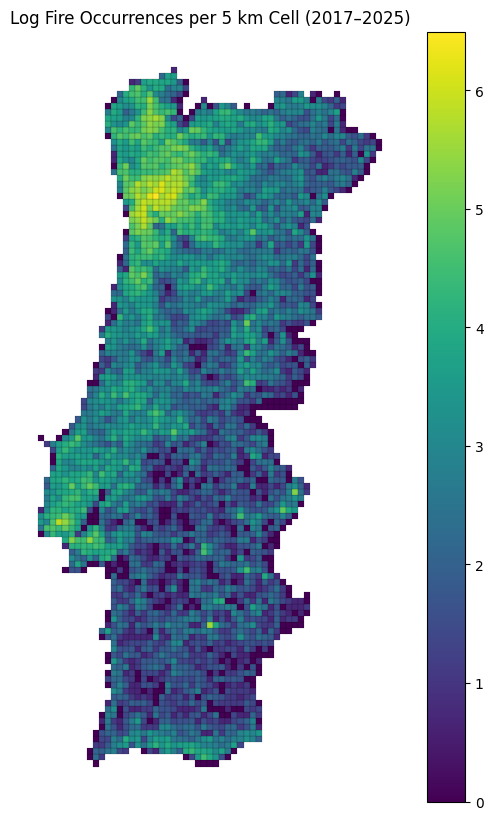

In [11]:
ax = grid_fire_counts.plot(
    column="log_fire_count",
    figsize=(7, 10),
    legend=True,
    edgecolor="black",
    linewidth=0.1
)

ax.set_title(
    "Log Fire Occurrences per 5 km Cell (2017–2025)"
)
ax.set_axis_off()

plt.show()

This is the second and final exploratory visual retained in the notebook.

Across 2017–2025:

- **3,511 cells** recorded at least one wildfire;
- **311 of the 3,822 cells** recorded none.

The logarithmic transformation is used only for visualization because a small number of cells contain very high occurrence counts.

## 5. Weekly modelling calendar and target

The prediction calendar uses Monday reference dates.

For a reference date such as `2024-07-15`:

- predictors may use information only through **2024-07-14**;
- the target interval is **2024-07-15 to 2024-07-21**;
- `fire_next_7_days = 1` if at least one fire occurs in the cell during that interval.

Only weeks whose entire seven-day target interval remains inside **May–October** are retained.

In [12]:
fires_with_cells["fire_date"] = (
    fires_with_cells["DataHoraAlerta"]
    .dt.normalize()
)

reference_dates = pd.date_range(
    start="2017-05-01",
    end="2025-10-31",
    freq="W-MON"
)

reference_dates = reference_dates[
    reference_dates.month.isin(
        range(5, 11)
    )
]

weekly_calendar = pd.DataFrame({
    "reference_date": reference_dates
})

weekly_calendar["target_end"] = (
    weekly_calendar["reference_date"]
    + pd.Timedelta(days=6)
)

weekly_calendar = (
    weekly_calendar[
        weekly_calendar["target_end"]
        .dt.month
        .isin(range(5, 11))
    ]
    .reset_index(drop=True)
)

iso = (
    weekly_calendar[
        "reference_date"
    ]
    .dt.isocalendar()
)

weekly_calendar["iso_year"] = (
    iso["year"]
)
weekly_calendar["iso_week"] = (
    iso["week"]
)

print(
    "Reference weeks:",
    len(weekly_calendar)
)
print(
    weekly_calendar[
        "reference_date"
    ].min(),
    "to",
    weekly_calendar[
        "reference_date"
    ].max()
)

Reference weeks: 229
2017-05-01 00:00:00 to 2025-10-20 00:00:00


The final calendar contains **229 weekly reference dates** between 2017 and 2025.

In [13]:
cells_id = (
    grid_5km_portugal[
        ["cell_id"]
    ]
    .copy()
)

model_dataset = cells_id.merge(
    weekly_calendar,
    how="cross"
)

fires_with_cells["reference_date"] = (
    fires_with_cells["fire_date"]
    - pd.to_timedelta(
        fires_with_cells[
            "fire_date"
        ].dt.weekday,
        unit="D"
    )
)

weekly_fires = (
    fires_with_cells
    .groupby(
        ["cell_id", "reference_date"]
    )
    .size()
    .reset_index(
        name="fire_count_week"
    )
)

model_dataset = (
    model_dataset
    .merge(
        weekly_fires,
        on=[
            "cell_id",
            "reference_date"
        ],
        how="left"
    )
)

model_dataset["fire_count_week"] = (
    model_dataset["fire_count_week"]
    .fillna(0)
    .astype(int)
)

model_dataset["fire_next_7_days"] = (
    model_dataset["fire_count_week"]
    > 0
).astype(int)

print("Dataset shape:", model_dataset.shape)
print(
    model_dataset[
        "fire_next_7_days"
    ].value_counts()
)
print(
    model_dataset[
        "fire_next_7_days"
    ].value_counts(
        normalize=True
    )
)

Dataset shape: (875238, 7)
fire_next_7_days
0    825098
1     50140
Name: count, dtype: int64
fire_next_7_days
0    0.942713
1    0.057287
Name: proportion, dtype: float64


### Target distribution

The resulting dataset contains **875,238 cell-week observations**:

- `0 — No fire`: **825,098 (94.27%)**
- `1 — Fire`: **50,140 (5.73%)**

This class imbalance is part of the real prediction problem and should remain intact in validation/test data.

Consequences for later modelling:

- accuracy is not an appropriate primary metric;
- PR-AUC will be a key model-selection metric;
- class weighting can be considered during model training;
- all models must use the same temporal target definition and leakage-free feature windows.

In [14]:
target_by_year = (
    model_dataset
    .groupby("iso_year")[
        "fire_next_7_days"
    ]
    .agg(
        positive_weeks="sum",
        total_weeks="count",
        positive_rate="mean"
    )
)

target_by_year[
    "positive_rate"
] = (
    target_by_year[
        "positive_rate"
    ] * 100
)

target_by_year.round(2)

,positive_weeks,total_weeks,positive_rate
iso_year,,,
2017,9280,99372,9.34
2018,5973,95550,6.25
2019,6063,95550,6.35
2020,5828,95550,6.10
2021,4514,99372,4.54
2022,5261,99372,5.29
2023,3996,99372,4.02
2024,3880,95550,4.06
2025,5345,95550,5.59


## 6. Save the shared project inputs

Two artefacts are produced:

- `model_dataset_weekly.parquet` — the base `cell × week` table and wildfire target;
- `grid_5km_portugal.parquet` — the fixed spatial grid used by all subsequent data sources.

The base dataset deliberately retains audit columns such as `iso_year`, `iso_week`, `target_end` and `fire_count_week`. Model-specific feature selection can remove them later.

In [15]:
model_dataset.to_parquet(
    "../data/interim/model_dataset_weekly.parquet",
    engine="pyarrow",
    index=False
)

grid_5km_portugal.to_parquet(
    "../data/interim/grid_5km_portugal.parquet",
    index=False
)

saved_dataset = pd.read_parquet(
    "../data/interim/model_dataset_weekly.parquet"
)

print(
    "Saved model dataset:",
    saved_dataset.shape
)
print(
    "Saved grid:",
    grid_5km_portugal.shape
)

Saved model dataset: (875238, 7)
Saved grid: (3822, 4)


## 7. Final decisions carried forward

- Study period: **2017–2025**
- Main modelling season: **May–October**
- Spatial unit: **fixed 5 × 5 km grid**
- Grid size: **3,822 cells**
- Temporal unit: **Monday reference week**
- Number of reference weeks: **229**
- Target: wildfire occurs within the following **7 days**
- Base dataset size: **875,238 rows**
- Positive target rate: **5.73%**
- Geographic inclusion rule: ETRS89 fire point must lie inside Mainland Portugal

The next notebook adds antecedent ERA5-Land meteorological features without changing this common `cell_id × reference_date` index.